# Passive Brachiation Report

This notebook is the report entry point. Each section calls the corresponding cached `run()` function and displays the generated figure. Set `FORCE = True` to recompute all sections.

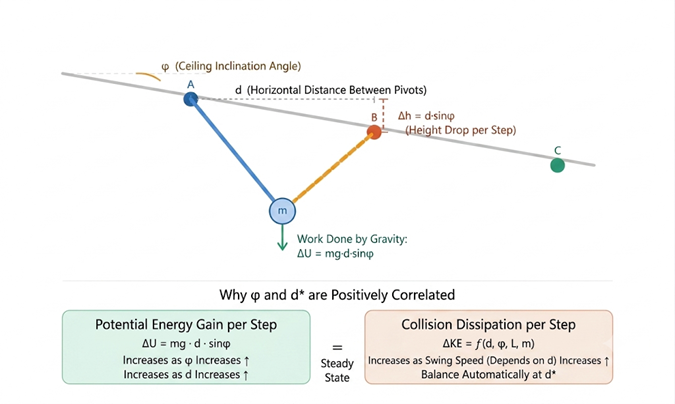

In [28]:
from IPython.display import HTML, Image, display
from pathlib import Path
from PIL import Image as PILImage, ImageSequence
import base64
import io
import json
import uuid

FORCE = False
RESULTS_DIR = "results"
ANIMATION_SPEED = 1.0  # Initial playback speed; 1.0 means simulated 1 s plays in real 1 s.

def show(result, name="main"):
    path = result.figure(name)
    print(path)
    display(Image(filename=str(path)))

def play_gif(path, speed=ANIMATION_SPEED, width=None):
    """Display a GIF as a frame player with live speed control."""
    path = Path(path)
    frames = []
    durations = []
    with PILImage.open(path) as image:
        for frame in ImageSequence.Iterator(image):
            durations.append(max(10, int(frame.info.get("duration", image.info.get("duration", 40)))))
            buffer = io.BytesIO()
            frame.convert("RGBA").save(buffer, format="PNG")
            frames.append("data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("ascii"))
    player_id = "gif_player_" + uuid.uuid4().hex
    width_style = "" if width is None else f"width:{int(width)}px;"
    html = f"""
    <div id="{player_id}" style="font-family: system-ui, sans-serif; max-width: 920px;">
      <div style="display:flex; align-items:center; gap:12px; margin:6px 0;">
        <button type="button" class="toggle">pause</button>
        <label>speed
          <input class="speed" type="range" min="0.1" max="4" step="0.1" value="{float(speed):.2f}" style="width:220px; vertical-align:middle;">
          <span class="speed_value">{float(speed):.1f}</span>x
        </label>
      </div>
      <img class="frame" style="{width_style} max-width:100%; height:auto; border:1px solid #ddd;" alt="{path.name}">
    </div>
    <script>
    (() => {{
      const root = document.getElementById({json.dumps(player_id)});
      const frames = {json.dumps(frames)};
      const durations = {json.dumps(durations)};
      const img = root.querySelector(".frame");
      const slider = root.querySelector(".speed");
      const value = root.querySelector(".speed_value");
      const toggle = root.querySelector(".toggle");
      let index = 0;
      let timer = null;
      let playing = true;
      function schedule() {{
        if (timer) clearTimeout(timer);
        if (!playing || frames.length <= 1) return;
        const speed = Math.max(0.1, parseFloat(slider.value) || 1.0);
        value.textContent = speed.toFixed(1);
        timer = setTimeout(() => {{
          index = (index + 1) % frames.length;
          img.src = frames[index];
          schedule();
        }}, Math.max(10, durations[index] / speed));
      }}
      slider.addEventListener("input", schedule);
      toggle.addEventListener("click", () => {{
        playing = !playing;
        toggle.textContent = playing ? "pause" : "play";
        schedule();
      }});
      img.src = frames[0];
      schedule();
    }})();
    </script>
    """
    print(path)
    display(HTML(html))


## 1. Physical Model

Ordinary underactuated two-link brachiation model, including workspace motion, state portraits, and energy history for a representative passive rollout.

[part1_modeling] cache hit (c870a1f8ce67); reused 1 figure(s).
results\part1_modeling_c870a1f8ce67__main.png


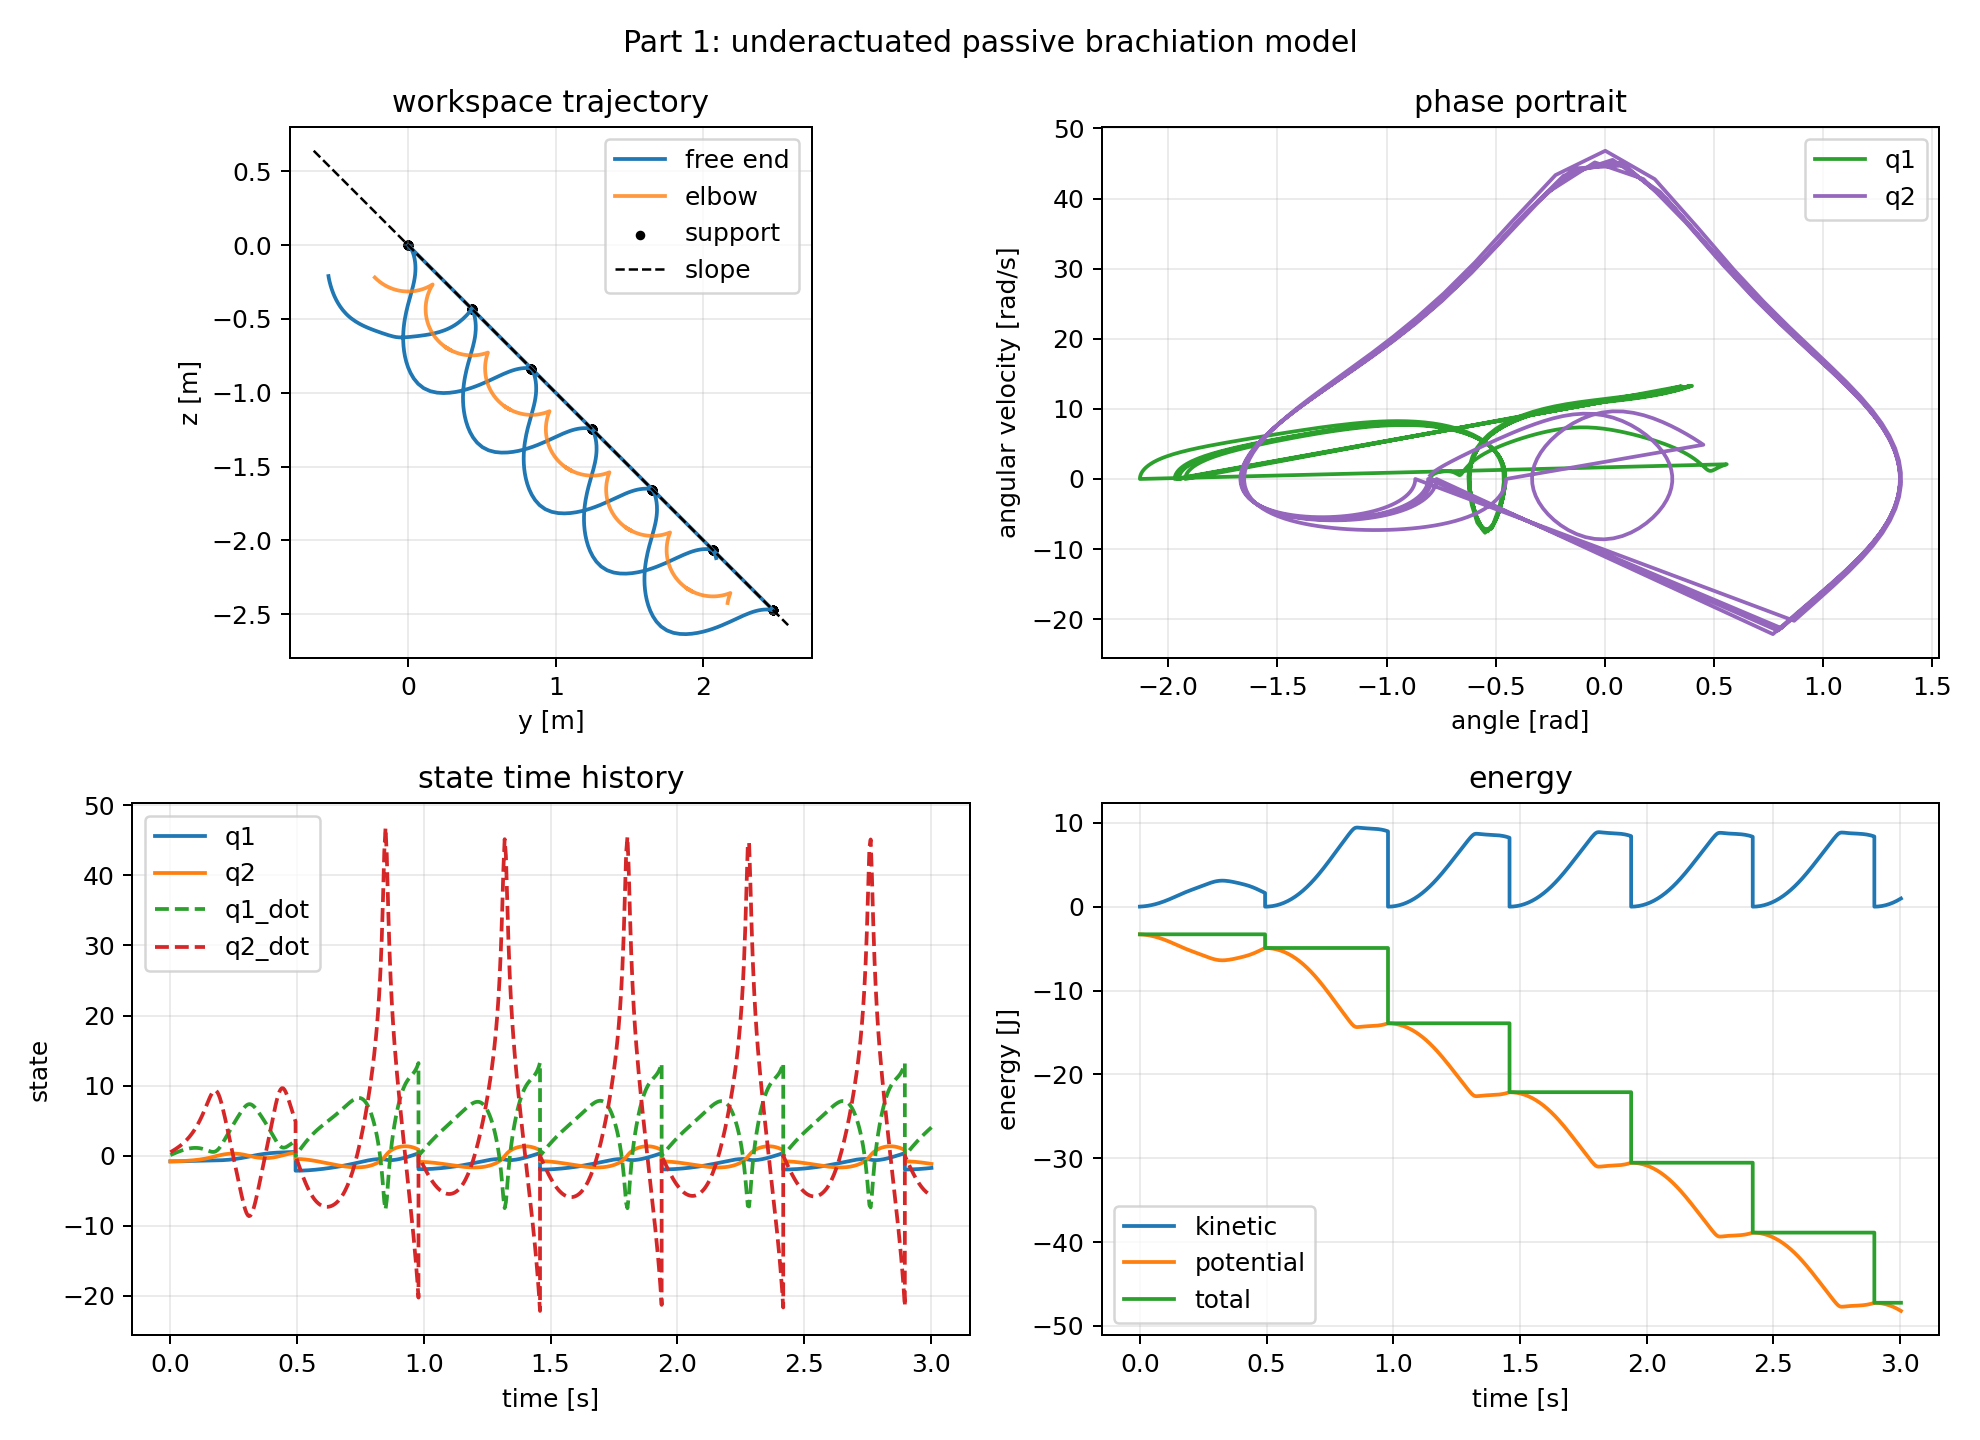

In [29]:
from run_part1_modeling import run as run_part1

part1 = run_part1(force=FORCE, results_dir=RESULTS_DIR)
show(part1)

## 2. Passive Steady Gait

For a fixed parameter set, find a passive fixed gait and visualize its repeated state trajectory and energy evolution.

[part2_steady_state] cache hit (f63b735f7e13); reused 1 figure(s).
results\part2_steady_state_f63b735f7e13__main.png


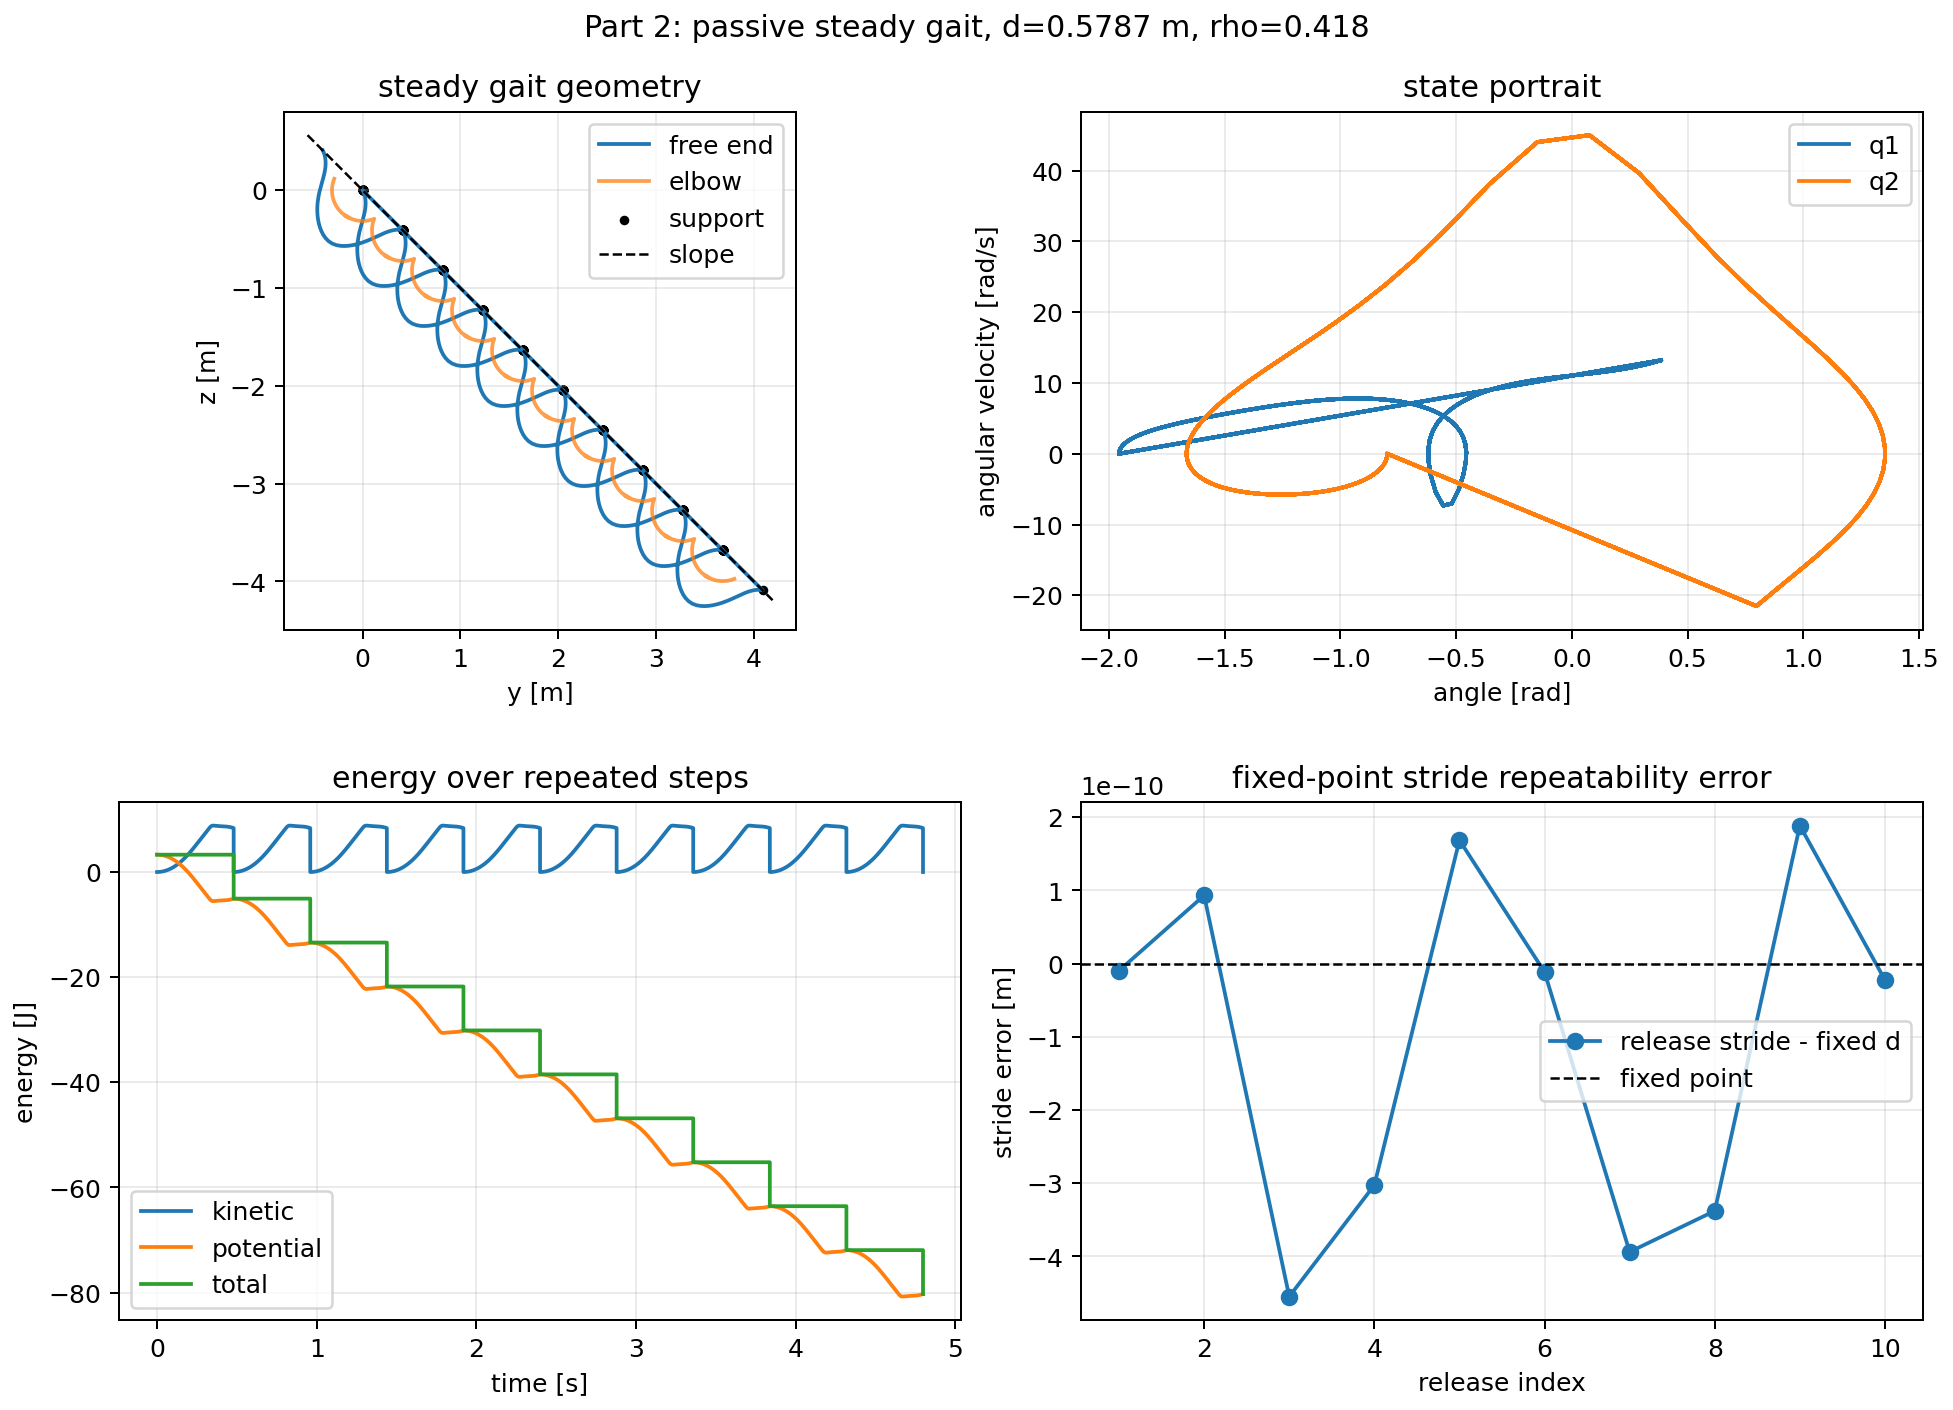

{'branch': 'negative',
 'd_fixed': 0.5786887322285337,
 'legal': True,
 'period': 1,
 'release_stride_mean': 0.5786887321203377,
 'spectral_radius': 0.4183269107671527,
 'stable': True,
 'validation_error': 3.296062311974879e-10}

In [30]:
from run_part2_steady_state import run as run_part2

part2 = run_part2(force=FORCE, results_dir=RESULTS_DIR)
show(part2)
part2.summary

## 3a. COM Sweep

Sweep symmetric COM offset and track how the passive fixed gait evolves.

[com_sweep] cache hit (e25fb62fb64a); reused 1 figure(s).
results\com_sweep_e25fb62fb64a__main.png


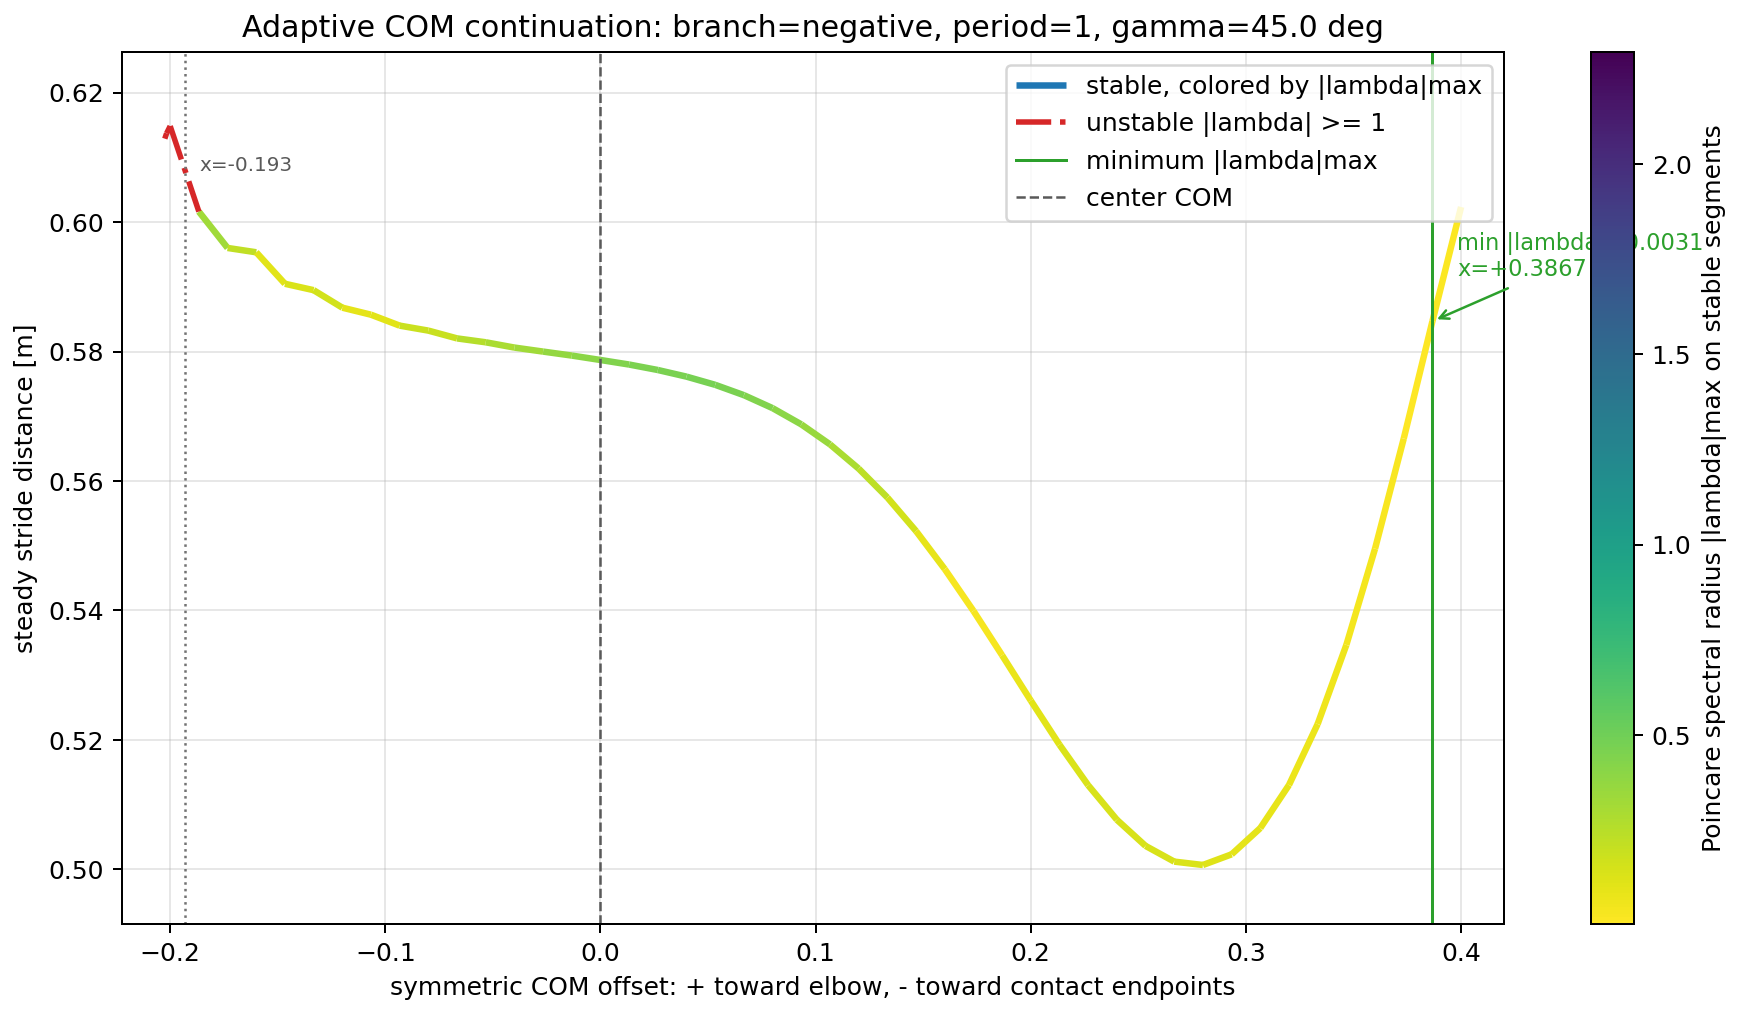

In [31]:
from run_com_sweep import run as run_com_sweep

part3a = run_com_sweep(force=FORCE, results_dir=RESULTS_DIR)
show(part3a)

## 3b. Lower-Limit Fold / Saddle-Node Search

Analyze the suspected lower-limit instability and its stable/unstable branch structure.

[com_special_point] cache hit (caafd073c91b); reused 2 figure(s).
results\com_special_point_caafd073c91b__fine_scan.png


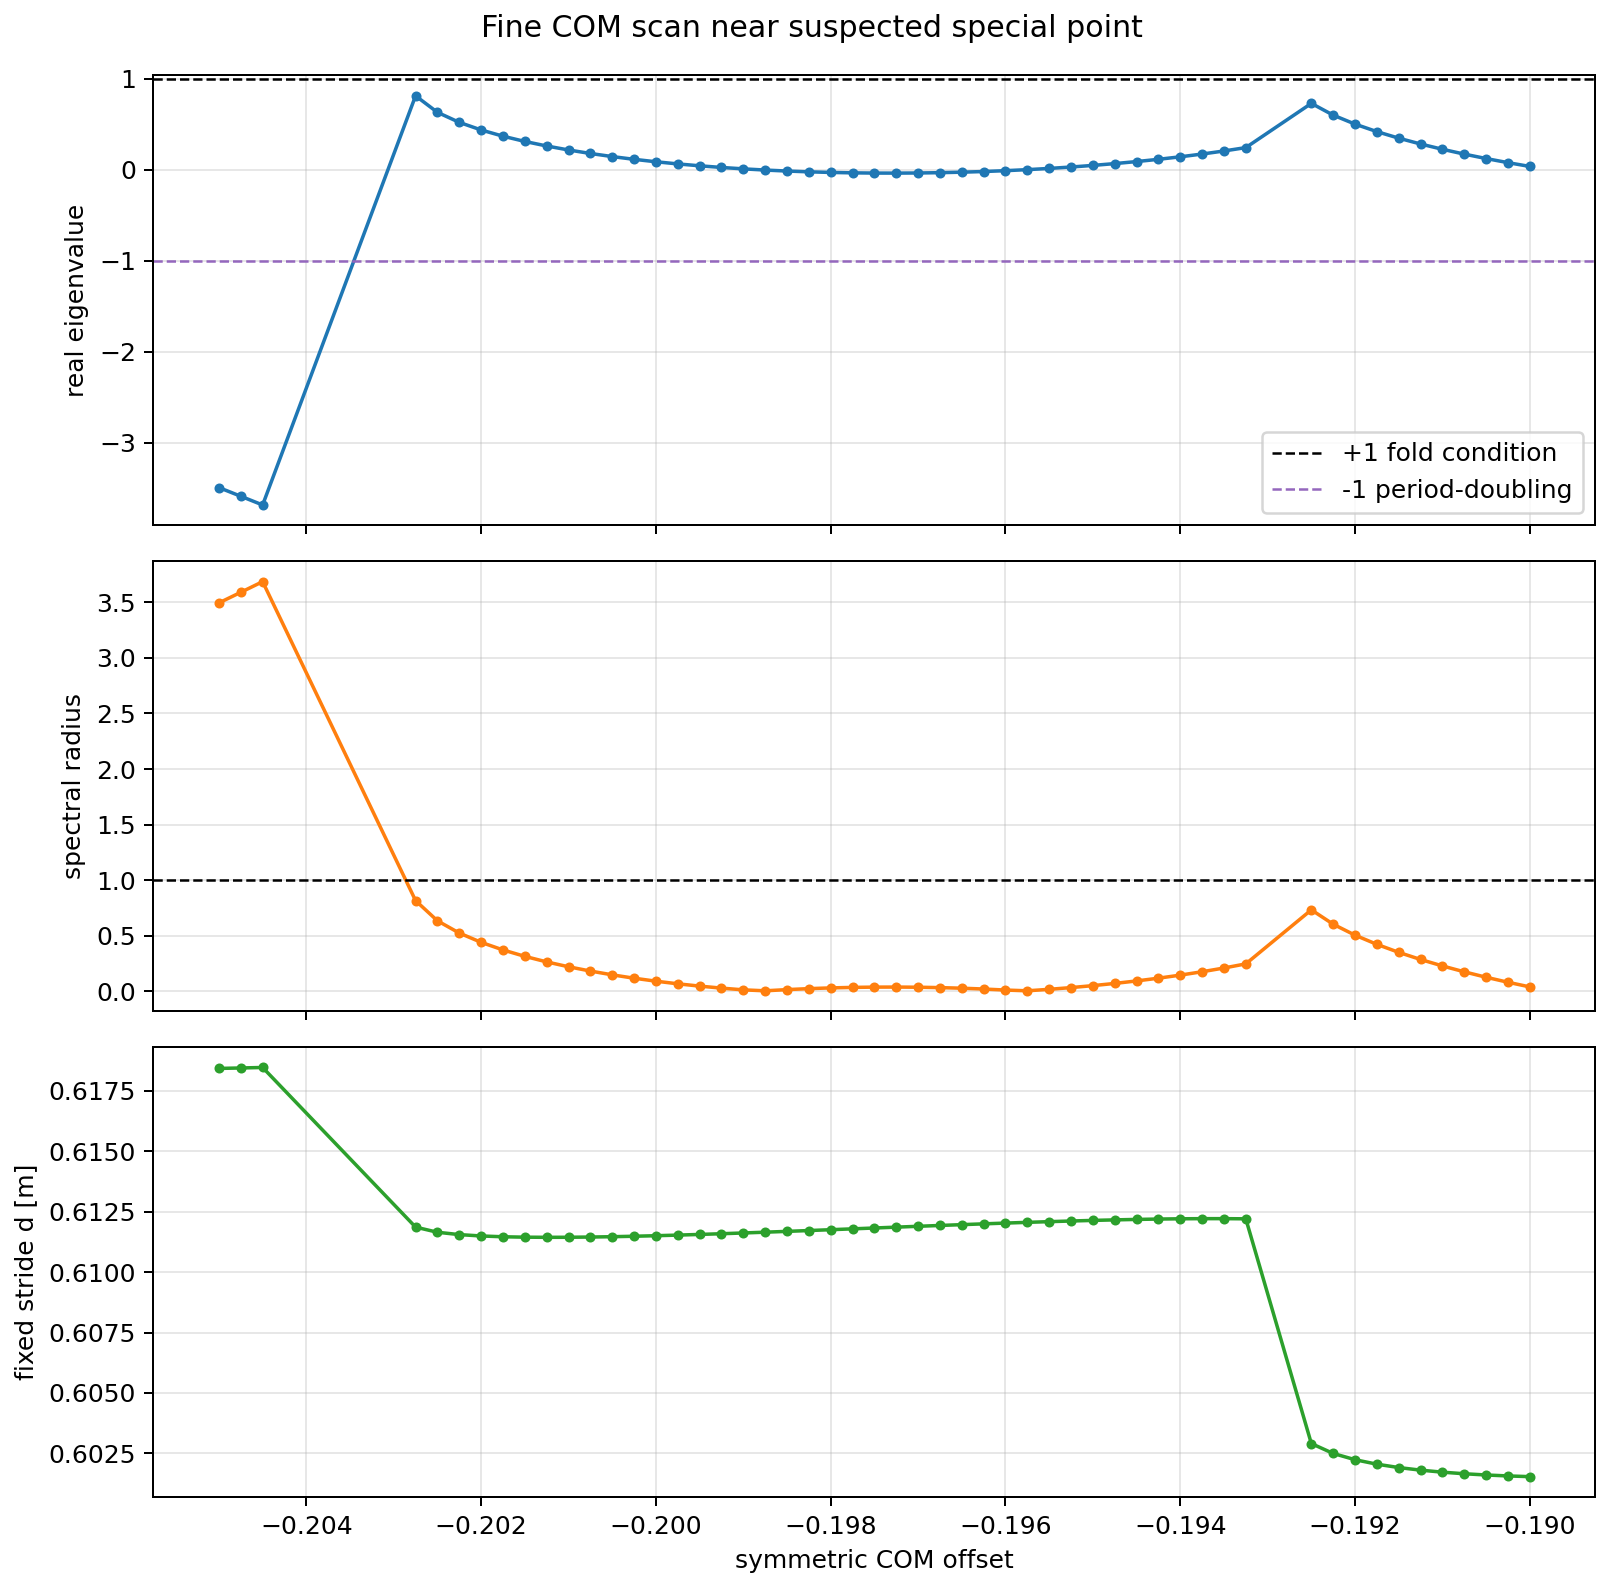

results\com_special_point_caafd073c91b__fold_arms.png


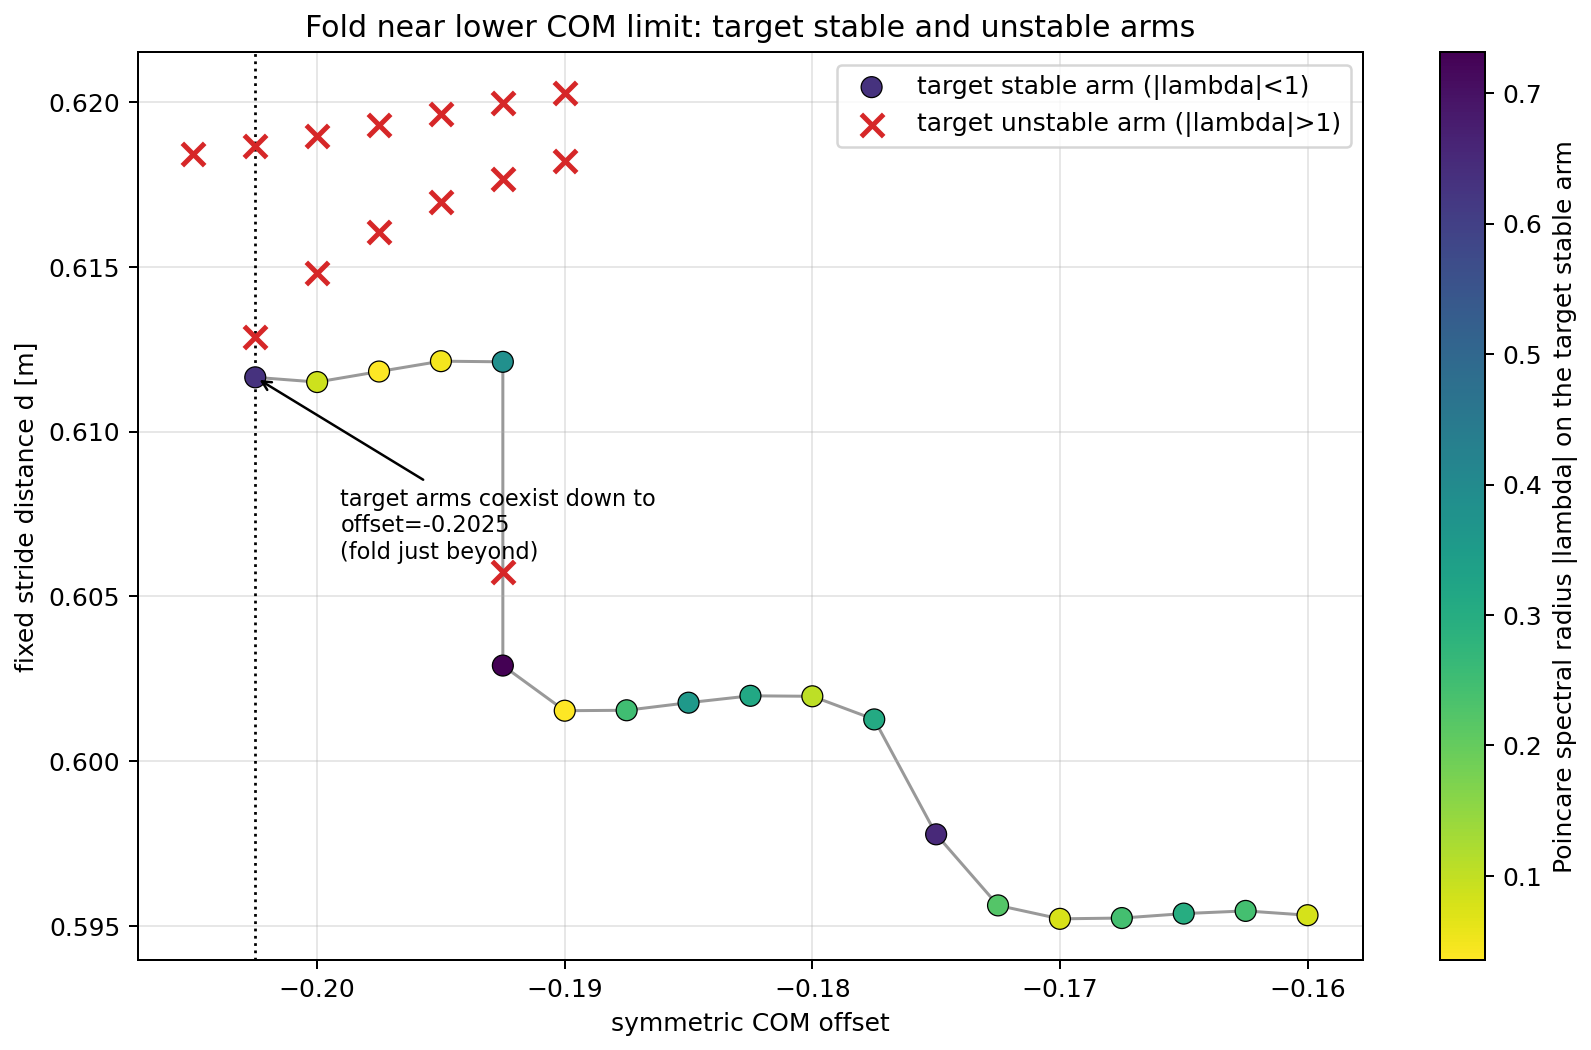

In [32]:
from run_com_special_point_analysis import run as run_special

part3b = run_special(force=FORCE, results_dir=RESULTS_DIR)
show(part3b, "fine_scan")
show(part3b, "fold_arms")

## 3c. Slope Sweep

Using the COM-selected operating point, vary slope angle and monitor stability/legal fixed-gait continuation.

[gamma_sweep] cache hit (a78193178db3); reused 1 figure(s).
results\gamma_sweep_a78193178db3__main.png


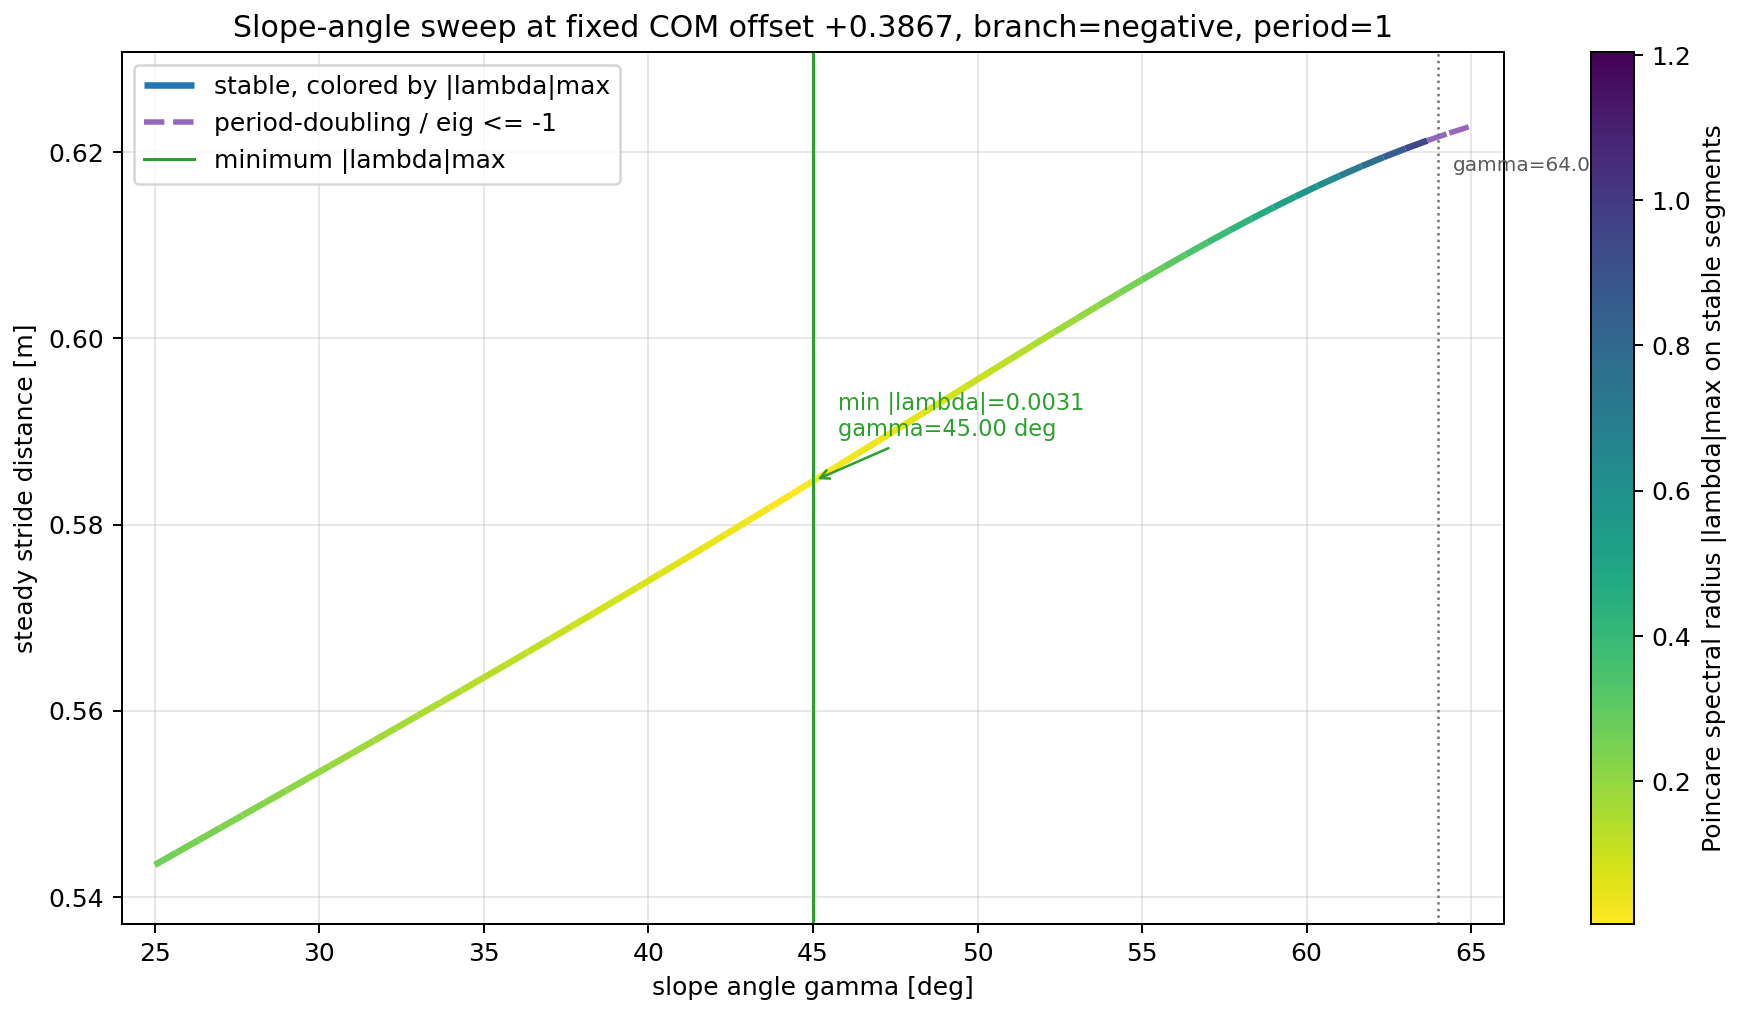

In [33]:
from run_gamma_sweep import run as run_gamma

part3c = run_gamma(force=FORCE, results_dir=RESULTS_DIR)
show(part3c)

## 4. One-Step Basin Probe

Plot `d_k -> d_{k+1}` error maps for automatically selected stable, near-critical, and unstable COM offsets.

[com_stride_map_family] cache hit (83eb2629728b); reused 1 figure(s).
results\com_stride_map_family_83eb2629728b__main.png


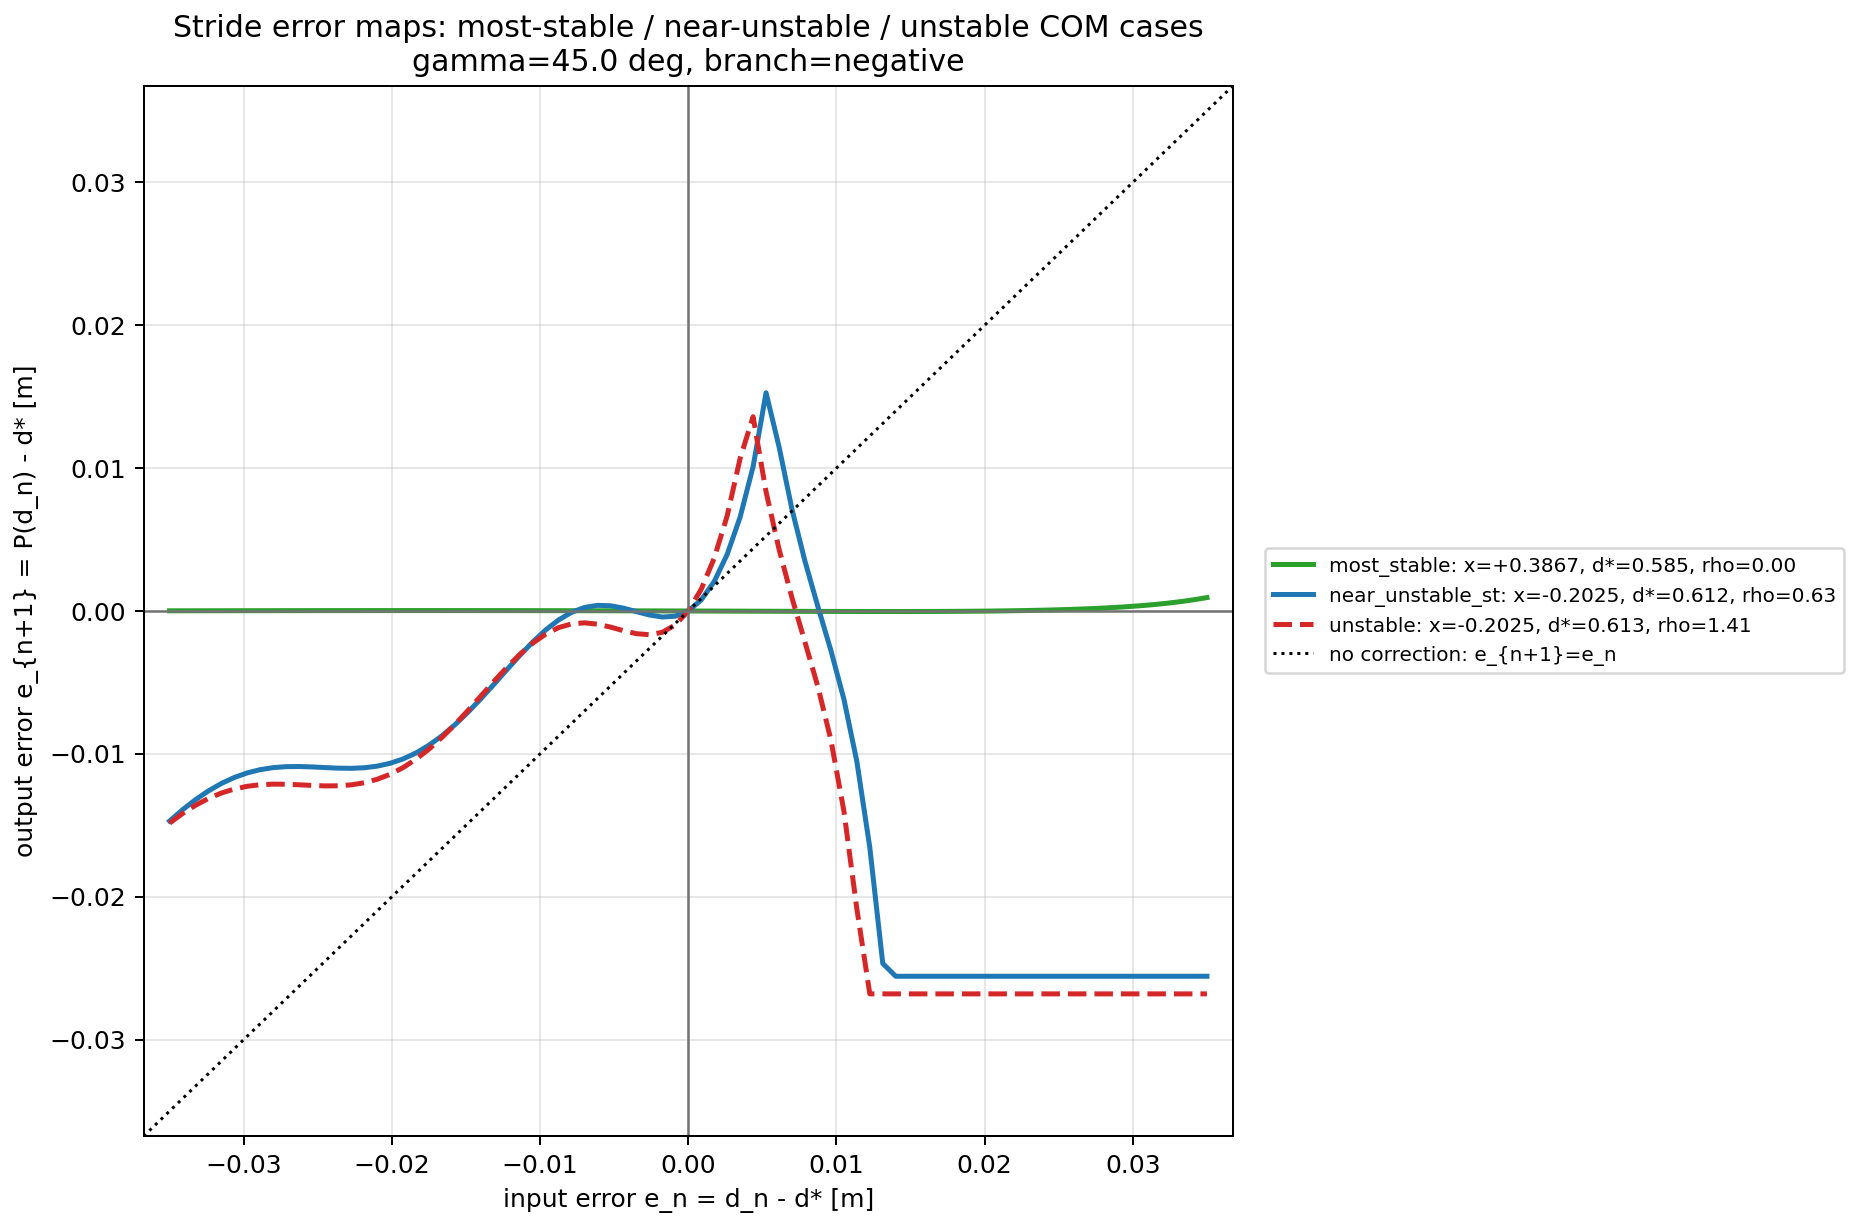

In [34]:
from run_com_stride_map_family import run as run_stride_family

part4 = run_stride_family(force=FORCE, results_dir=RESULTS_DIR)
show(part4)

## 5. Normal-Velocity Compensation

As the slope is lowered, inject endpoint normal velocity at release to preserve the same target stride.

[normal_velocity_gamma_continuation] cache hit (c5ac797ba48b); reused 1 figure(s).
results\normal_velocity_gamma_continuation_c5ac797ba48b__main.png


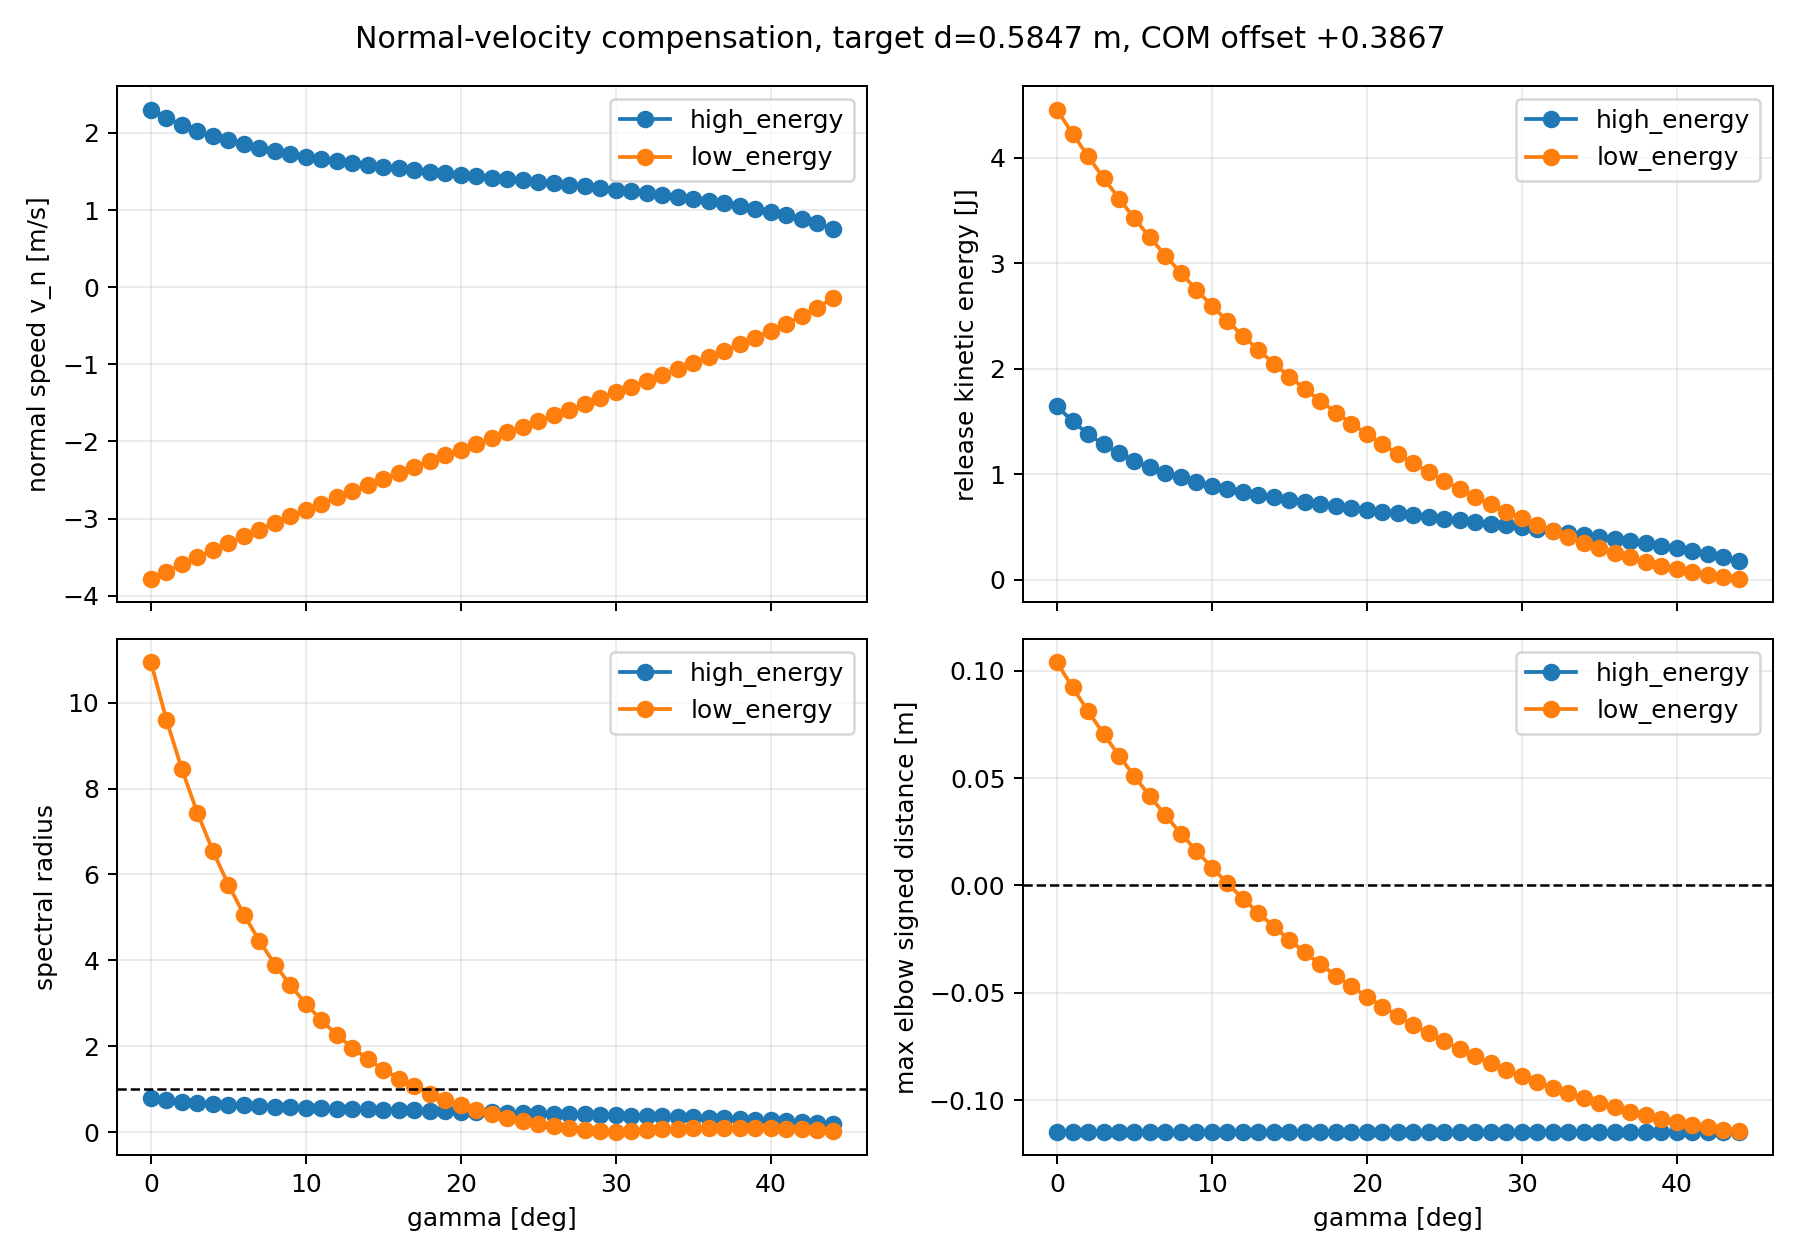

In [35]:
from run_normal_velocity_gamma_continuation import run as run_normal_velocity

part5 = run_normal_velocity(force=FORCE, results_dir=RESULTS_DIR)
show(part5)

## 6. Normal-Impulse Compensation

Replace the prescribed normal velocity with a physically motivated endpoint normal impulse.

[normal_impulse_gamma_continuation] cache hit (5922025c5471); reused 1 figure(s).
results\normal_impulse_gamma_continuation_5922025c5471__main.png


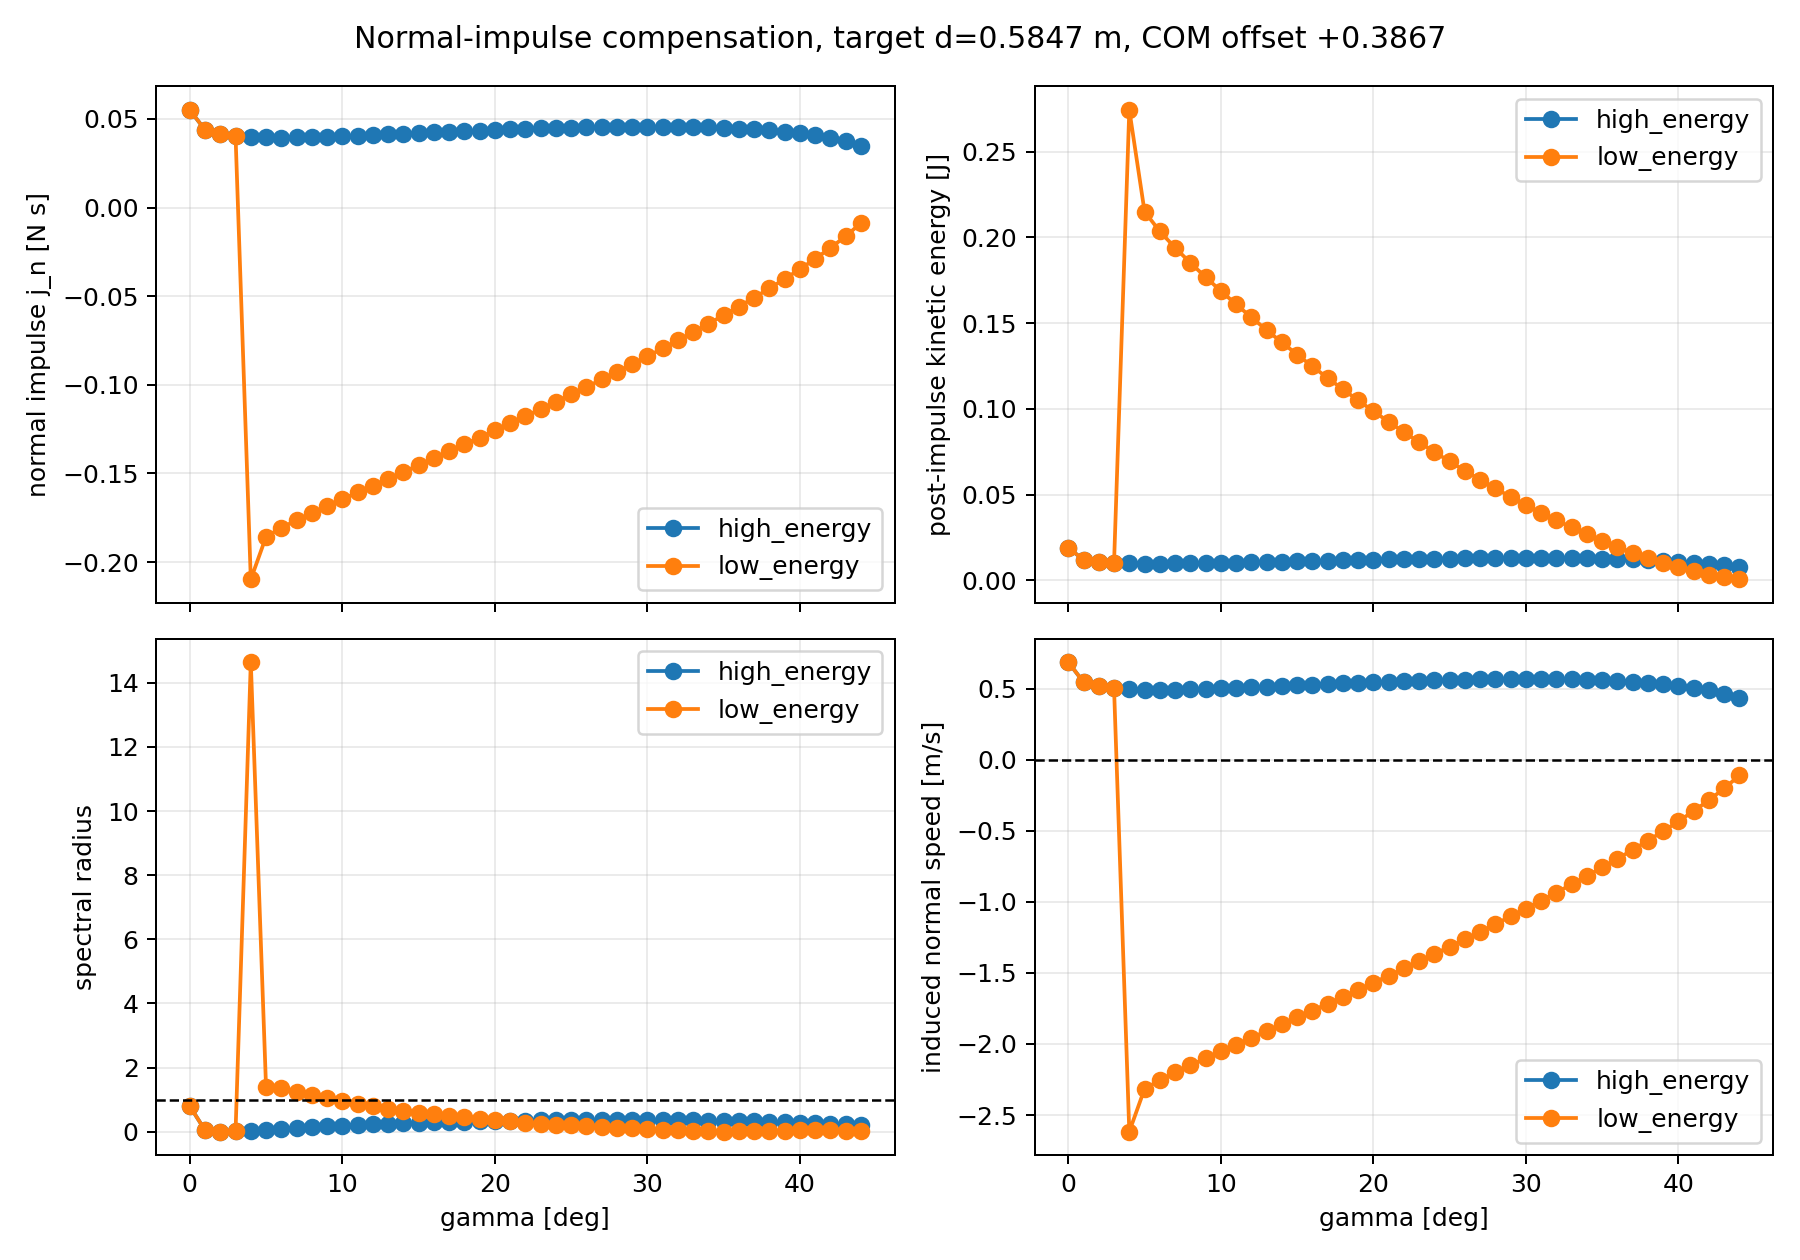

In [36]:
from run_normal_impulse_gamma_continuation import run as run_normal_impulse

part6 = run_normal_impulse(force=FORCE, results_dir=RESULTS_DIR)
show(part6)

## 7. Free Initial Velocity Under Non-Penetration

Allow any endpoint velocity direction that does not point into the wall, and select the legal stable minimum-energy solution.

[free_initial_velocity_gamma_sweep] cache hit (f2084d6b3609); reused 1 figure(s).
results\free_initial_velocity_gamma_sweep_f2084d6b3609__main.png


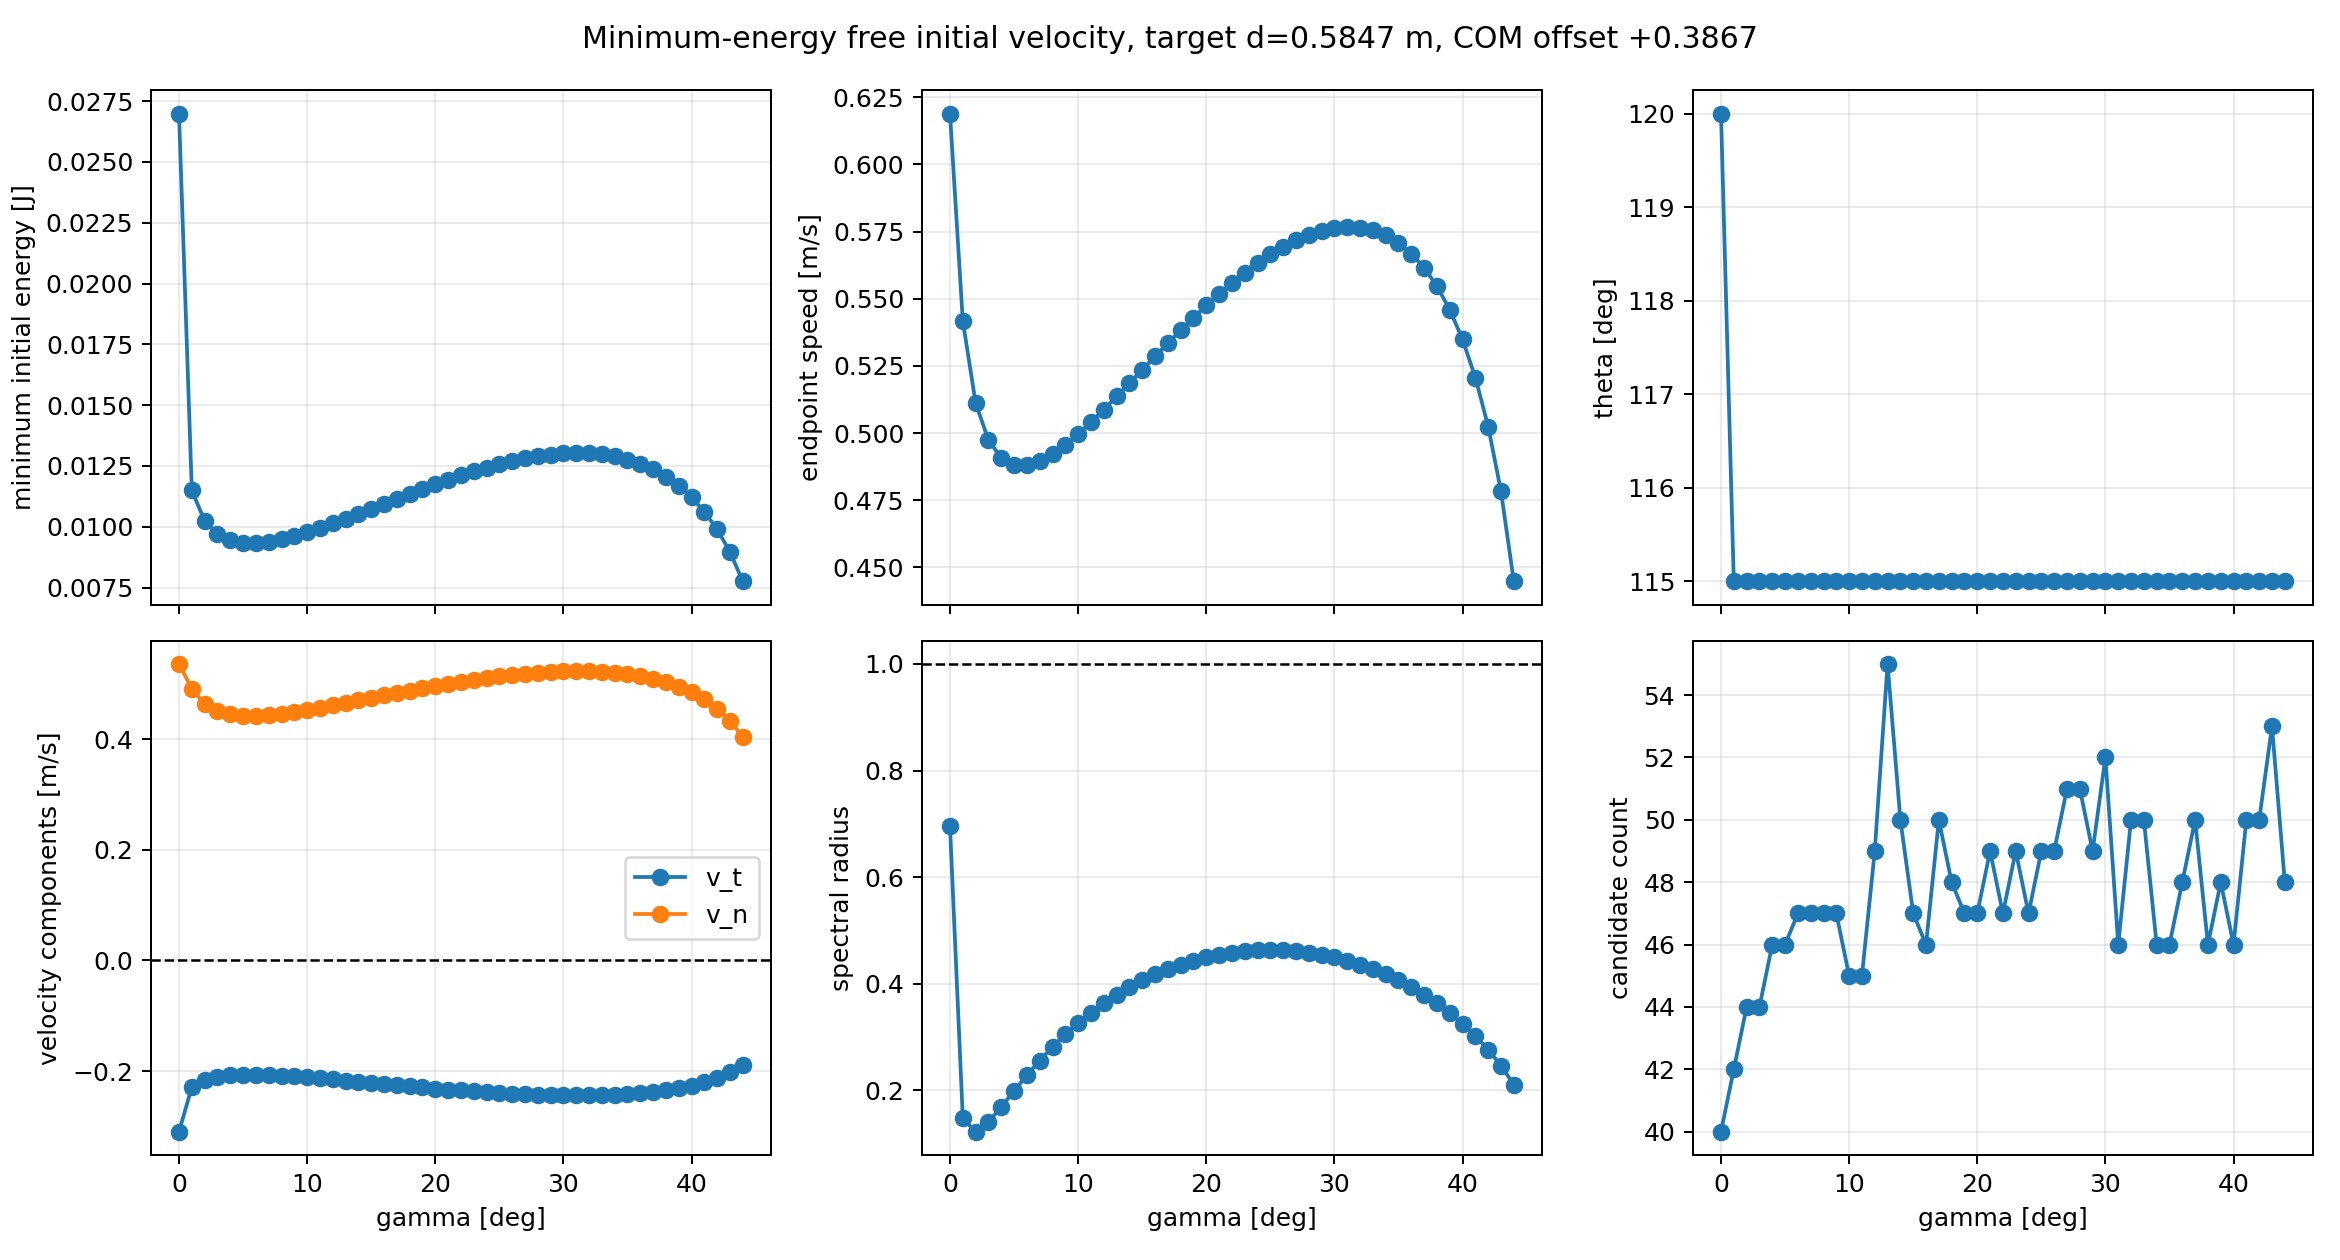

In [37]:
from run_free_initial_velocity_gamma_sweep import run as run_free_velocity

part7 = run_free_velocity(force=FORCE, results_dir=RESULTS_DIR)
show(part7)

## 8. Gamma=0 Passive Reference

Before applying direct collocation or iLQR, roll out the selected gamma=0 minimum-energy passive reference once and inspect the state and kinetic-energy evolution.

In [ ]:
from run_gamma0_passive_reference import run as run_gamma0_reference, animation_path

part8_ref = run_gamma0_reference(force=FORCE, results_dir=RESULTS_DIR)
show(part8_ref)
gif_path = animation_path(part8_ref, results_dir=RESULTS_DIR)
print(gif_path)
play_gif(gif_path)
part8_ref.summary

## 8a. Direct Collocation Control

Use the gamma=0 minimum-energy free-velocity gait as a reference, then solve a direct-collocation elbow-torque tracking problem. The figure shows torque, system energy, state residual, and external work.

In [ ]:
from run_direct_collocation_gamma0_reference import run as run_dircol, animation_path as dircol_animation_path

part8a = run_dircol(force=FORCE, results_dir=RESULTS_DIR)
show(part8a)
dircol_gif = dircol_animation_path(part8a, results_dir=RESULTS_DIR)
print(dircol_gif)
play_gif(dircol_gif)
part8a.summary

## 8b. iLQR Control

Use the same gamma=0 pre-impact swing reference and compare a local iLQR controller against direct collocation.

In [ ]:
from run_ilqr_gamma0_reference import run as run_ilqr
from run_direct_collocation_gamma0_reference import animation_path as control_animation_path

part8b = run_ilqr(force=FORCE, results_dir=RESULTS_DIR)
show(part8b)
ilqr_gif = control_animation_path(part8b, results_dir=RESULTS_DIR, part="ilqr_gamma0_reference")
print(ilqr_gif)
play_gif(ilqr_gif)
part8b.summary

## 9. Partial-Loss Instantaneous Collision

Switch collision mode so that the system releases at the instant of impact while retaining part of its kinetic energy, then continue the legal/stable fixed gait in the retention parameter.

In [ ]:
from run_part9_partial_loss import run as run_part9, animation_path as part9_animation_path

part9 = run_part9(force=FORCE, results_dir=RESULTS_DIR)
show(part9)
show(part9, "gamma4_rollout")
part9_gif = part9_animation_path(part9, results_dir=RESULTS_DIR)
print(part9_gif)
play_gif(part9_gif)
part9.summary